In [4]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import scipy.stats
from fractions import Fraction
import math
import time

In [5]:
#zadanie 1a

def generate_Exp(lam, n):
    U = np.random.uniform(0, 1, n)
    return -np.log(U) / lam

def generate_Cauchy(mid, scale, n):
    U = np.random.uniform(0, 1, n)
    return mid + scale * np.tan(np.pi * (U - 0.5))

def generate_normal(mean, sqrt_var, n):
    U = np.random.uniform(0, 1, n)
    return scipy.stats.norm.ppf(U, loc=mean, scale=sqrt_var)

In [6]:
#zadanie 1b

def generate_geom(p, n):
    U = np.random.uniform(0, 1, n)
    return np.ceil(np.log(1 - U) / np.log(1 - p))

def generate_Poisson(lam, n):
    U = np.random.uniform(0, 1, n)
    X = []
    for i in range(n):
        p = np.exp(-lam)
        distr = p
        x = 0

        while U[i] > distr:
            x += 1
            p *= lam / x
            distr += p
        X.append(x)
    return X

print(generate_geom(0.4, 10))
print(generate_Poisson(2, 10))

[8. 3. 1. 2. 3. 1. 3. 1. 1. 4.]
[3, 0, 2, 4, 2, 1, 2, 1, 4, 6]


In [7]:
#zadanie 1c

def table_lookup(X, P):

    frac = [Fraction(p).limit_denominator() for p in P]
    
    denominators = [f.denominator for f in frac]
    common_denominator = math.lcm(*denominators)
    
    table = []
    for X, frac in zip(X, frac):
        num = (frac.numerator * (common_denominator // frac.denominator))
        table.extend([X] * num)

    return np.random.choice(table)

X = [1, 2, 3]
P = [1/6, 1/2, 1/3]

print(table_lookup(X, P))

2


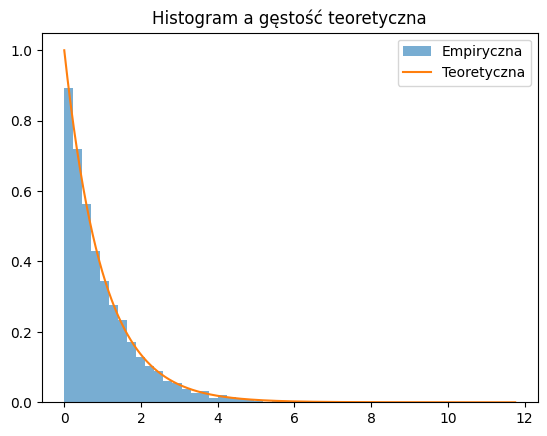

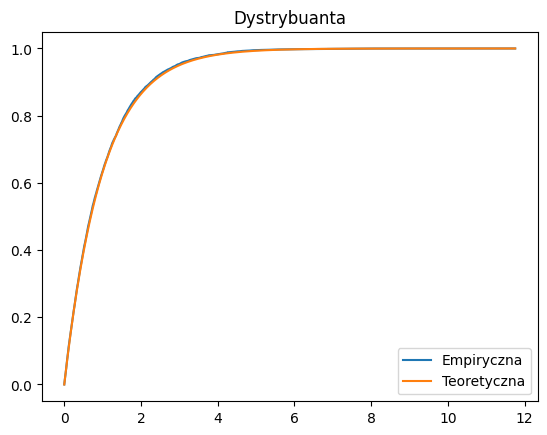

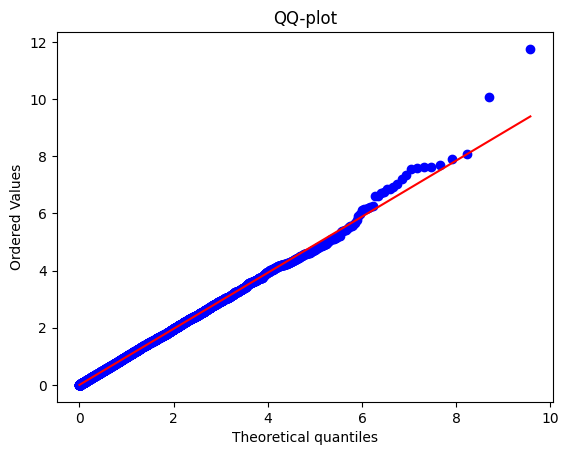

Średnia empiryczna: 0.9823662723907942
Średnia teoretyczna: 1.0
Wariancja empiryczna: 0.9606400997861547
Wariancja teoretyczna: 1.0
Test KS: D = 0.008519963804873854 p-value = 0.4597791078765586
Hipoteza zerowa zaakceptowana
Czas działania generatora własnego: 0.0
Czas działania generatora wbudowanego: 0.0009975433349609375


In [8]:
N = 10000
lambda_ = 1
alfa = 0.2

start = time.time()
dane = generate_Exp(lambda_, N)
czas_custom = time.time() - start

start = time.time()
dane_builtin = np.random.exponential(1/lambda_, N)
czas_builtin = time.time() - start

plt.hist(dane, bins=50, density=True, alpha=0.6, label='Empiryczna')
x = np.linspace(0, np.max(dane), 1000)
plt.plot(x, scipy.stats.expon(scale=1/lambda_).pdf(x), label='Teoretyczna')
plt.title("Histogram a gęstość teoretyczna")
plt.legend()
plt.show()

ecdf = np.sort(dane)
p = np.arange(1, N + 1) / N
plt.plot(ecdf, p, label='Empiryczna')
plt.plot(x, scipy.stats.expon(scale=1/lambda_).cdf(x), label='Teoretyczna')
plt.title("Dystrybuanta")
plt.legend()
plt.show()

scipy.stats.probplot(dane, dist="expon", sparams=(0, 1/lambda_), plot=plt)
plt.title("QQ-plot")
plt.show()

print("Średnia empiryczna:", np.mean(dane))
print("Średnia teoretyczna:", 1/lambda_)

print("Wariancja empiryczna:", np.var(dane))
print("Wariancja teoretyczna:", 1/(lambda_**2))

D, p_value = scipy.stats.kstest(dane, 'expon', args=(0, 1/lambda_))
print("Test KS: D =", D, "p-value =", p_value)
print("Hipoteza zerowa", "zaakceptowana" if p_value > alfa else "odrzucona")

print("Czas działania generatora własnego:", czas_custom)
print("Czas działania generatora wbudowanego:", czas_builtin)

In [9]:
#zadanie 3

def odwrotna_dystrybuanta(F, U, delta_x=0.001, x_min=-10, x_max=10):
    x = x_min
    while x <= x_max:
        if F(x) >= U:
            return x
        x += delta_x
    return x_max

lambda_ = 1
F_exp = lambda x: scipy.stats.expon.cdf(x, scale=1/lambda_)

U = np.random.uniform(0, 1)

x_num = odwrotna_dystrybuanta(F_exp, U)
x_true = -np.log(1 - U) / lambda_

print(f"u = {U}")
print(f"Metoda numeryczna: x = {x_num}")
print(f"Wartość rzeczywista: x = {x_true}")

u = 0.9581806319052051
Metoda numeryczna: x = 3.1749999999996588
Wartość rzeczywista: x = 3.17439569521549


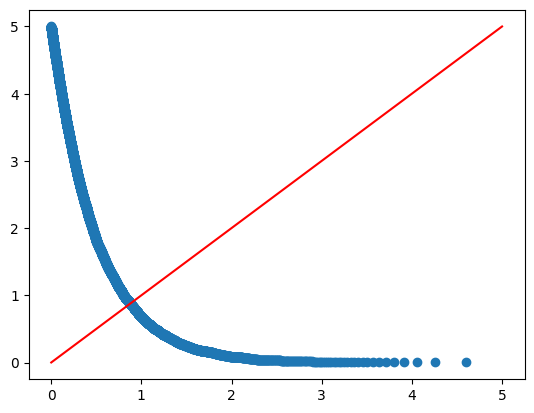

In [10]:
#zadanie 4

def drawqq(X, distr):
    X.sort()
    N = len(X)
    Q = [distr(i/N) for i in range(1,N+1)]
    plt.scatter(Q, X)
    plt.plot(X, X, 'r')
    plt.show()

lista = np.random.uniform(0,5, 10000)
def distr(x):
    return -np.log(x) / 2

drawqq(lista, distr)